In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:

import os
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/cleaned", exist_ok=True)


In [4]:
os.listdir("data")


['cleaned', 'raw']

In [5]:
os.listdir("data/raw")

[]

In [6]:
import os
os.listdir("/content/drive/MyDrive")[:5]


['Colab Notebooks']

In [7]:
import os

matches = []
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "olist_orders_dataset.csv" in files:
        matches.append(root)

matches[:10], len(matches)


(['/content/drive/MyDrive/Colab Notebooks/Ecommerce-Customer-Analytics-ETL/data/raw'],
 1)

In [8]:
raw_path = matches[0]
os.listdir(raw_path)


['olist_order_payments_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'product_category_name_translation.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv']

In [9]:
import pandas as pd
orders = pd.read_csv(os.path.join(raw_path, "olist_orders_dataset.csv"))
customers = pd.read_csv(os.path.join(raw_path, "olist_customers_dataset.csv"))
order_items = pd.read_csv(os.path.join(raw_path, "olist_order_items_dataset.csv"))
payments = pd.read_csv(os.path.join(raw_path, "olist_order_payments_dataset.csv"))
products = pd.read_csv(os.path.join(raw_path, "olist_products_dataset.csv"))
reviews = pd.read_csv(os.path.join(raw_path, "olist_order_reviews_dataset.csv"))

print("orders:", orders.shape)
print("customers:", customers.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("products:", products.shape)
print("reviews:", reviews.shape)

orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
payments: (103886, 5)
products: (32951, 9)
reviews: (99224, 7)


Checking missing values & duplicates (ETL validation)

In [10]:
tables = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "reviews": reviews
}

for name, df in tables.items():
    print("\n---", name.upper(), "---")
    print("Rows, Cols:", df.shape)
    print("Duplicates:", df.duplicated().sum())
    print("Missing values (top 10):")
    miss = df.isnull().sum().sort_values(ascending=False)
    print(miss[miss > 0].head(10))


--- ORDERS ---
Rows, Cols: (99441, 8)
Duplicates: 0
Missing values (top 10):
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

--- CUSTOMERS ---
Rows, Cols: (99441, 5)
Duplicates: 0
Missing values (top 10):
Series([], dtype: int64)

--- ORDER_ITEMS ---
Rows, Cols: (112650, 7)
Duplicates: 0
Missing values (top 10):
Series([], dtype: int64)

--- PAYMENTS ---
Rows, Cols: (103886, 5)
Duplicates: 0
Missing values (top 10):
Series([], dtype: int64)

--- PRODUCTS ---
Rows, Cols: (32951, 9)
Duplicates: 0
Missing values (top 10):
product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
dtype: int64

--- REVIEWS ---
Rows, Cols: (99224, 7)
Duplicates: 0
Missing values (top 10):
review_comment_title      8765

In [11]:
orders_raw = orders.copy()
customers_raw = customers.copy()
order_items_raw = order_items.copy()
payments_raw = payments.copy()
products_raw = products.copy()
reviews_raw = reviews.copy()


Convert dates in Orders

In [12]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_cols].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [13]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["shipping_days"] = (
    orders["order_delivered_customer_date"] - orders["order_delivered_carrier_date"]
).dt.days

orders["approval_days"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.days

orders[["delivery_days", "shipping_days", "approval_days"]].describe()

,delivery_days,shipping_days,approval_days
count,96476.000000,96475.000000,99281.000000
mean,12.094086,8.878310,0.269800
std,9.551746,8.746088,0.986202
min,0.000000,-17.000000,0.000000
25%,6.000000,4.000000,0.000000
50%,10.000000,7.000000,0.000000
75%,15.000000,12.000000,0.000000
max,209.000000,205.000000,187.000000


shipping_days min = -17

That means order_delivered_carrier_date is sometimes after order_delivered_customer_date

In [14]:
orders["shipping_days"].describe()


,shipping_days
count,96475.000000
mean,8.878310
std,8.746088
min,-17.000000
25%,4.000000
50%,7.000000
75%,12.000000
max,205.000000


In [15]:
orders.loc[orders["shipping_days"] < 0, "shipping_days"] = None


In [16]:
orders["shipping_days"].describe()


,shipping_days
count,96452.000000
mean,8.881330
std,8.744759
min,0.000000
25%,4.000000
50%,7.000000
75%,12.000000
max,205.000000


Clean PRODUCTS missing values

In [17]:
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

num_cols_products = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in num_cols_products:
    products[col] = products[col].fillna(products[col].median())

Clean REVIEWS missing comment fields

In [18]:
reviews["review_comment_title"] = reviews["review_comment_title"].fillna("")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("")

In [19]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["purchase_day"] = orders["order_purchase_timestamp"].dt.day
orders["purchase_weekday"] = orders["order_purchase_timestamp"].dt.day_name()

orders[["purchase_year", "purchase_month", "purchase_weekday"]].head()

,purchase_year,purchase_month,purchase_weekday
0,2017,10,Monday
1,2018,7,Tuesday
2,2018,8,Wednesday
3,2017,11,Saturday
4,2018,2,Tuesday


In [20]:
cleaned_path = raw_path.replace("/raw", "/cleaned")
os.makedirs(cleaned_path, exist_ok=True)

cleaned_path

'/content/drive/MyDrive/Colab Notebooks/Ecommerce-Customer-Analytics-ETL/data/cleaned'

In [21]:
orders.to_csv(os.path.join(cleaned_path, "orders_cleaned.csv"), index=False)
customers.to_csv(os.path.join(cleaned_path, "customers_cleaned.csv"), index=False)
order_items.to_csv(os.path.join(cleaned_path, "order_items_cleaned.csv"), index=False)
payments.to_csv(os.path.join(cleaned_path, "payments_cleaned.csv"), index=False)
products.to_csv(os.path.join(cleaned_path, "products_cleaned.csv"), index=False)
reviews.to_csv(os.path.join(cleaned_path, "reviews_cleaned.csv"), index=False)

print(os.listdir(cleaned_path))

['orders_cleaned.csv', 'order_items_cleaned.csv', 'reviews_cleaned.csv', 'customers_cleaned.csv', 'payments_cleaned.csv', 'products_cleaned.csv']


In [22]:
orders = pd.read_csv(os.path.join(cleaned_path, "orders_cleaned.csv"))
customers = pd.read_csv(os.path.join(cleaned_path, "customers_cleaned.csv"))
order_items = pd.read_csv(os.path.join(cleaned_path, "order_items_cleaned.csv"))
payments = pd.read_csv(os.path.join(cleaned_path, "payments_cleaned.csv"))
products = pd.read_csv(os.path.join(cleaned_path, "products_cleaned.csv"))
reviews = pd.read_csv(os.path.join(cleaned_path, "reviews_cleaned.csv"))

orders.shape, customers.shape, order_items.shape, payments.shape, products.shape, reviews.shape

((99441, 15), (99441, 5), (112650, 7), (103886, 5), (32951, 9), (99224, 7))

Merge Order Items and Products

In [23]:
items_products = order_items.merge(products, on="product_id", how="left")
items_products.shape


(112650, 15)

Merge Orders and Customers

In [24]:
orders_customers = orders.merge(customers, on="customer_id", how="left")
orders_customers.shape


(99441, 19)

Payments aggregated per order

In [25]:
payments_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max")
).reset_index()

payments_agg.head()


,order_id,total_payment_value,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


Reviews aggregated per order

In [26]:
reviews_agg = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

reviews_agg.head()


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [27]:
master = (
    items_products
    .merge(orders_customers, on="order_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
)

master.shape

(112650, 36)

In [28]:
master.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,purchase_month,purchase_day,purchase_weekday,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,payment_installments,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,...,9,13,Wednesday,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19,2.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,...,4,26,Wednesday,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83,3.0,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,59.0,695.0,...,1,14,Sunday,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87,5.0,5.0


revenue metrics

In [29]:
master["revenue"] = master["price"] + master["freight_value"]
master["profit_proxy"] = master["price"] - master["freight_value"]

master[["revenue", "profit_proxy"]].describe()


,revenue,profit_proxy
count,112650.000000,112650.000000
mean,140.644059,100.663419
std,190.724394,177.670283
min,6.080000,-140.530000
25%,55.220000,24.520000
50%,92.320000,56.290000
75%,157.937500,111.830000
max,6929.310000,6540.690000


Total Revenue + Total Orders + Total Customers

In [30]:
master["revenue"] = master["price"] + master["freight_value"]


In [31]:
total_revenue = master["revenue"].sum()
total_orders = master["order_id"].nunique()
total_customers = master["customer_unique_id"].nunique()

total_revenue, total_orders, total_customers


(np.float64(15843553.24), 98666, 95420)

The dataset contains 98,666 orders from 95,420 unique customers, generating a total revenue of ~15.84M, showing strong transaction volume for analysis.

Top 10 Product Categories by Revenue

In [41]:
top_categories = (
    master.groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories


,revenue
product_category_name,
beleza_saude,1441248.07
relogios_presentes,1305541.61
cama_mesa_banho,1241681.72
esporte_lazer,1156656.48
informatica_acessorios,1059272.40
moveis_decoracao,902511.79
utilidades_domesticas,778397.77
cool_stuff,719329.95
automotivo,685384.32


The dataset contains 98,666 orders from 95,420 unique customers, generating a total revenue of ~15.84M, showing strong transaction volume for analysis.

Top 10 States by Revenue

In [33]:
top_categories = (
    master.groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories


,revenue
product_category_name,
beleza_saude,1441248.07
relogios_presentes,1305541.61
cama_mesa_banho,1241681.72
esporte_lazer,1156656.48
informatica_acessorios,1059272.40
moveis_decoracao,902511.79
utilidades_domesticas,778397.77
cool_stuff,719329.95
automotivo,685384.32


The highest revenue-generating categories are Health & Beauty (beleza_saude) and Watches & Gifts (relogios_presentes), indicating strong customer demand in lifestyle-related products.

Average Review Score by Category

In [34]:
review_by_category = (
    master.groupby("product_category_name")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

review_by_category

,review_score
product_category_name,
cds_dvds_musicais,4.642857
fashion_roupa_infanto_juvenil,4.500000
livros_interesse_geral,4.446266
construcao_ferramentas_ferramentas,4.444444
flores,4.419355
livros_importados,4.400000
livros_tecnicos,4.363636
malas_acessorios,4.315257
alimentos_bebidas,4.312274


Categories like CDs/DVDs/Music and Kids Fashion have the highest average review scores, suggesting better customer satisfaction and product experience in these segments.

Delivery Days vs Review Score

In [35]:
delivery_review = (
    master.groupby("review_score")["delivery_days"]
    .mean()
)

delivery_review

,delivery_days
review_score,
1.000000,19.157527
1.500000,14.388889
2.000000,15.354098
2.500000,16.000000
3.000000,13.564069
3.333333,22.000000
3.500000,12.482759
4.000000,11.747861
4.333333,3.000000


Categories like CDs/DVDs/Music and Kids Fashion have the highest average review scores, suggesting better customer satisfaction and product experience in these segments.

Monthly Revenue Trend

In [36]:
monthly_revenue = (
    master.groupby(["purchase_year", "purchase_month"])["revenue"]
    .sum()
    .reset_index()
    .sort_values(["purchase_year", "purchase_month"])
)

monthly_revenue.head()

,purchase_year,purchase_month,revenue
0,2016,9,354.75
1,2016,10,56808.84
2,2016,12,19.62
3,2017,1,137188.49
4,2017,2,286280.62


Monthly revenue patterns can be used to identify seasonal spikes and business growth trends, supporting forecasting and campaign planning.

Repeat Customers vs One-time Customers

In [37]:
customer_orders = master.groupby("customer_unique_id")["order_id"].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

repeat_customers, one_time_customers

(np.int64(2913), np.int64(92507))

Monthly revenue patterns can be used to identify seasonal spikes and business growth trends, supporting forecasting and campaign planning.

Top 10 Customers by Revenue

In [38]:
top_customers = (
    master.groupby("customer_unique_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,revenue
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,13664.08
da122df9eeddfedc1dc1f5349a1a690c,7571.63
763c8b1c9c68a0229c42c9fc6f662b93,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31
459bef486812aa25204be022145caa62,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
4007669dec559734d6f53e029e360987,6081.54
5d0a2980b292d049061542014e8960bf,4809.44
eebb5dda148d3893cdaf5b5ca3040ccb,4764.34


A small set of high-value customers contributes disproportionately to revenue, making them ideal targets for loyalty and personalized engagement strategies.

Payment Value vs Installments

In [39]:
installment_summary = (
    master.groupby("payment_installments")["total_payment_value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

installment_summary

,total_payment_value
payment_installments,
24.0,810.740882
20.0,568.072857
18.0,498.608421
10.0,435.174556
15.0,425.059239
16.0,395.081429
12.0,325.612393
8.0,312.662057
21.0,267.428000


Higher installment counts are associated with higher average payment values, suggesting customers use installments mainly for expensive purchases.

Freight Cost Impact

In [40]:
master["freight_ratio"] = master["freight_value"] / master["price"]

freight_ratio_by_state = (
    master.groupby("customer_state")["freight_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

freight_ratio_by_state

,freight_ratio
customer_state,
RO,0.594188
RR,0.589050
MA,0.549324
AC,0.511651
PB,0.511597
RN,0.506330
PI,0.499842
TO,0.499459
AM,0.498136


States like RO and RR have the highest freight-to-price ratios, indicating logistics costs are significantly higher in certain regions and may impact profitability.

##  Summary

- The dataset contains 98,666 orders from 95,420 unique customers, generating ~15.84M in revenue.
- Health & Beauty and Watches & Gifts are the top revenue-generating product categories.
- Delivery time impacts customer satisfaction, as low review scores tend to have longer average delivery days.
- Customer retention is low, with most customers being one-time buyers, showing a major opportunity for repeat purchase strategies.
- Freight cost ratios are significantly higher in certain states (e.g., RO, RR), suggesting regional logistics challenges that can affect profitability.


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)


Top 10 Categories by Revenue

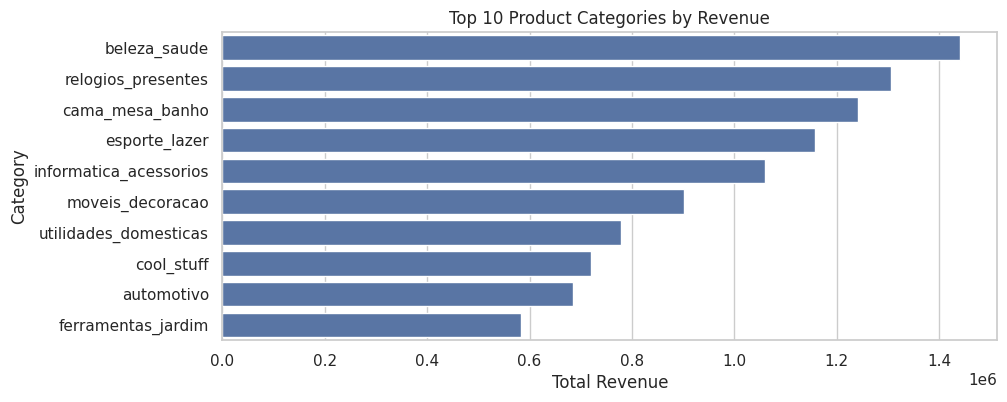

In [68]:
top10_cat = (
    master.groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(data=top10_cat, x="revenue", y="product_category_name")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.show()


Monthly Revenue Trend

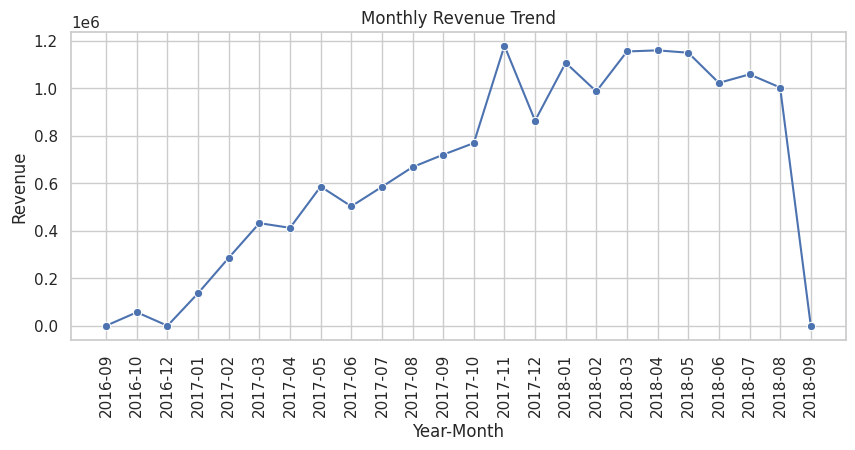

In [69]:
monthly_revenue = (
    master.groupby(["purchase_year", "purchase_month"])["revenue"]
    .sum()
    .reset_index()
    .sort_values(["purchase_year", "purchase_month"])
)

monthly_revenue["year_month"] = (
    monthly_revenue["purchase_year"].astype(str) + "-" +
    monthly_revenue["purchase_month"].astype(str).str.zfill(2)
)

sns.lineplot(data=monthly_revenue, x="year_month", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=90)
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.show()


One-time vs Repeat Customers

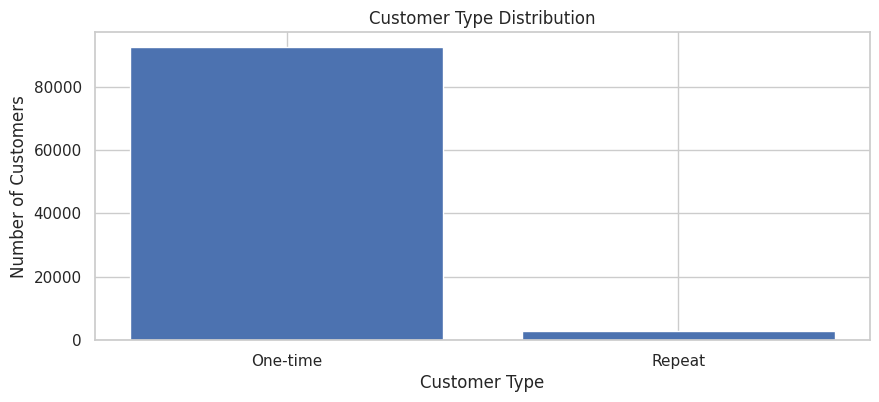

In [70]:
customer_orders = master.groupby("customer_unique_id")["order_id"].nunique()

repeat = (customer_orders > 1).sum()
one_time = (customer_orders == 1).sum()

cust_type = {"One-time": one_time, "Repeat": repeat}

plt.bar(cust_type.keys(), cust_type.values())
plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()


Delivery Days vs Review Score

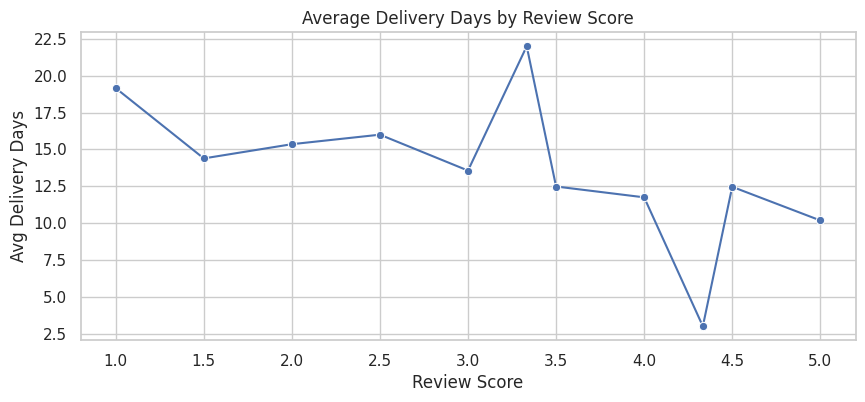

In [71]:
delivery_review = (
    master.groupby("review_score")["delivery_days"]
    .mean()
    .reset_index()
)

sns.lineplot(data=delivery_review, x="review_score", y="delivery_days", marker="o")
plt.title("Average Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Avg Delivery Days")
plt.show()


Freight Ratio by State

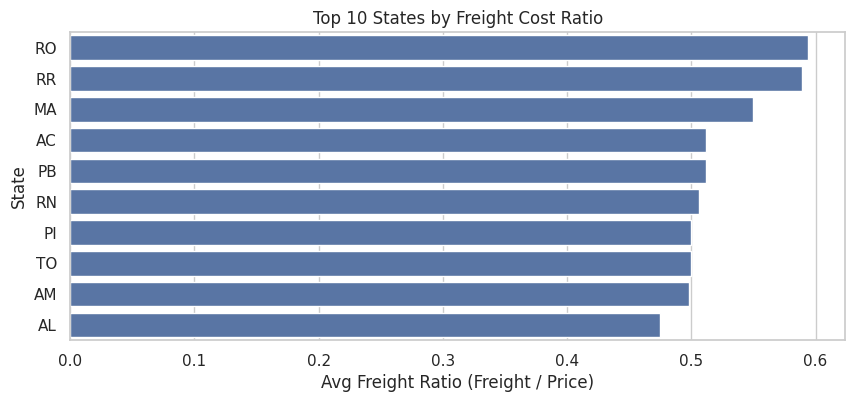

In [72]:
master["freight_ratio"] = master["freight_value"] / master["price"]

freight_state = (
    master.groupby("customer_state")["freight_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(data=freight_state, x="freight_ratio", y="customer_state")
plt.title("Top 10 States by Freight Cost Ratio")
plt.xlabel("Avg Freight Ratio (Freight / Price)")
plt.ylabel("State")
plt.show()


Review Score Distribution

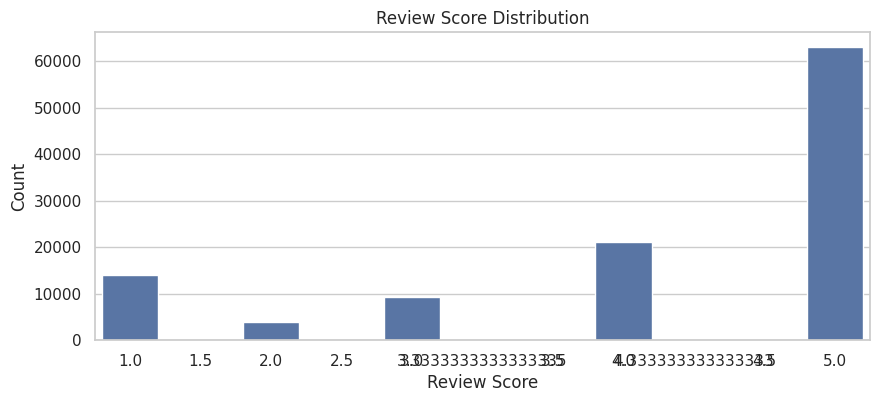

In [73]:
sns.countplot(data=master, x="review_score")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


Visualization Summary

- Revenue is concentrated in a small set of top product categories.
- Monthly revenue shows clear fluctuations, suggesting seasonality.
- Most customers are one-time buyers, highlighting retention opportunity.
- Longer delivery times are linked with lower review scores.
- Freight cost ratio varies by state, indicating regional logistics challenges.
- Review scores are skewed toward higher ratings, but low ratings exist and may be driven by delivery delays.